# Week 5: CV-Informed Sensor Feature Analysis

## Objective

This notebook applies computer vision feature extraction concepts to
time-series sensor data from the Aido Rover.

The analysis includes:

1. Data quality validation
2. Rolling-window feature extraction
3. Rate-of-change feature extraction
4. FFT frequency-domain feature extraction
5. Composite anomaly score calculation
6. Random Forest feature importance analysis
7. Fari interaction quality feature analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = Path("../data/synthetic_rover_data.csv")

rover_df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", rover_df.shape)

rover_df.head()

Dataset loaded successfully.
Shape: (12000, 11)


,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature,status
0,2026-07-01 00:00:00,43.072474,-89.400668,6.214978,101.499580,30.498199,27.707335,27.063768,29.265164,26.144969,Normal
1,2026-07-01 00:01:00,43.073330,-89.401182,2.904787,101.481014,31.638698,30.454532,24.826910,30.484939,27.499129,Fault
2,2026-07-01 00:02:00,43.073878,-89.401202,30.000000,98.925882,34.718033,29.222000,31.708100,32.937053,18.317683,Normal
3,2026-07-01 00:03:00,43.072368,-89.402706,5.984263,100.572100,36.340124,17.562884,36.368883,29.765023,23.060746,Normal
4,2026-07-01 00:04:00,43.073881,-89.402177,6.773406,102.499250,30.074116,27.359921,33.890405,34.695564,23.604358,Normal


# 1. Data Quality Assessment

Before feature engineering, the dataset is checked for:

- Row and column count
- Missing values
- Data types
- Duplicate rows
- Sensor value ranges
- Target-label distribution

In [3]:
print("Rows:", rover_df.shape[0])
print("Columns:", rover_df.shape[1])

Rows: 12000
Columns: 11


In [4]:
print(rover_df.columns.tolist())

['timestamp', 'latitude', 'longitude', 'lidar_distance', 'battery_soc', 'wheel_torque_1', 'wheel_torque_2', 'wheel_torque_3', 'wheel_torque_4', 'temperature', 'status']


In [5]:
quality_table = pd.DataFrame({
    "data_type": rover_df.dtypes.astype(str),
    "missing_count": rover_df.isnull().sum(),
    "missing_percent": (
        rover_df.isnull().mean() * 100
    ).round(2),
    "unique_values": rover_df.nunique()
})

quality_table

,data_type,missing_count,missing_percent,unique_values
timestamp,str,0,0.0,12000
latitude,float64,360,3.0,11640
longitude,float64,360,3.0,11640
lidar_distance,float64,0,0.0,11761
battery_soc,float64,0,0.0,12000
wheel_torque_1,float64,0,0.0,12000
wheel_torque_2,float64,0,0.0,12000
wheel_torque_3,float64,0,0.0,12000
wheel_torque_4,float64,0,0.0,12000
temperature,float64,0,0.0,12000


In [7]:
duplicate_count = rover_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [8]:
status_distribution = rover_df["status"].value_counts()
status_percentage = (
    rover_df["status"].value_counts(normalize=True) * 100
).round(2)

status_summary = pd.DataFrame({
    "count": status_distribution,
    "percentage": status_percentage
})

status_summary

,count,percentage
status,,
Normal,9613,80.11
Warning,1822,15.18
Fault,565,4.71


In [9]:
print(
    "Battery outside 0-100:",
    ((rover_df["battery_soc"] < 0) |
     (rover_df["battery_soc"] > 100)).sum()
)

print(
    "Negative LiDAR readings:",
    (rover_df["lidar_distance"] < 0).sum()
)

Battery outside 0-100: 112
Negative LiDAR readings: 1


In [10]:
rover_clean = rover_df.copy()

numeric_columns = rover_clean.select_dtypes(
    include=["number"]
).columns

rover_clean[numeric_columns] = (
    rover_clean[numeric_columns]
    .interpolate(limit_direction="both")
)

print(
    "Remaining missing numeric values:",
    rover_clean[numeric_columns].isnull().sum().sum()
)

Remaining missing numeric values: 0


### Data Quality Finding

The dataset contains missing sensor readings, especially in the GPS-related
columns. Numeric missing values were handled using interpolation because the
records represent a continuous time-series. Sensor range checks were also
performed before feature extraction.

In [12]:
WINDOW_SIZE = 20

In [13]:
rover_clean["battery_rolling_mean"] = (
    rover_clean["battery_soc"]
    .rolling(window=WINDOW_SIZE)
    .mean()
)

rover_clean["battery_rolling_std"] = (
    rover_clean["battery_soc"]
    .rolling(window=WINDOW_SIZE)
    .std()
)

In [14]:
rover_clean["lidar_rolling_mean"] = (
    rover_clean["lidar_distance"]
    .rolling(window=WINDOW_SIZE)
    .mean()
)

rover_clean["lidar_rolling_std"] = (
    rover_clean["lidar_distance"]
    .rolling(window=WINDOW_SIZE)
    .std()
)

In [15]:
rover_clean["battery_rate_of_change"] = (
    rover_clean["battery_soc"].diff()
)

rover_clean["lidar_rate_of_change"] = (
    rover_clean["lidar_distance"].diff()
)

In [16]:
rover_clean["battery_abs_rate_change"] = (
    rover_clean["battery_rate_of_change"].abs()
)

rover_clean["lidar_abs_rate_change"] = (
    rover_clean["lidar_rate_of_change"].abs()
)

In [17]:
def dominant_frequency(values):
    """
    Calculate the dominant FFT frequency of a rolling window.

    Parameters
    ----------
    values : array-like
        Sensor readings from one rolling window.

    Returns
    -------
    float
        Frequency with the largest non-zero FFT magnitude.
    """
    values = np.asarray(values)

    if len(values) < WINDOW_SIZE or np.isnan(values).any():
        return np.nan

    centered_values = values - np.mean(values)

    fft_values = np.fft.rfft(centered_values)
    fft_magnitude = np.abs(fft_values)
    frequencies = np.fft.rfftfreq(len(values))

    if len(fft_magnitude) <= 1:
        return 0.0

    dominant_index = np.argmax(fft_magnitude[1:]) + 1

    return frequencies[dominant_index]

In [18]:
def total_spectral_power(values):
    """
    Calculate total spectral power in one rolling window.

    Parameters
    ----------
    values : array-like
        Sensor readings from one rolling window.

    Returns
    -------
    float
        Sum of squared FFT magnitudes.
    """
    values = np.asarray(values)

    if len(values) < WINDOW_SIZE or np.isnan(values).any():
        return np.nan

    centered_values = values - np.mean(values)
    fft_values = np.fft.rfft(centered_values)

    return float(np.sum(np.abs(fft_values) ** 2))

In [19]:
torque_columns = [
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4"
]

In [20]:
for column in torque_columns:
    rover_clean[f"{column}_dominant_frequency"] = (
        rover_clean[column]
        .rolling(window=WINDOW_SIZE)
        .apply(dominant_frequency, raw=True)
    )

    rover_clean[f"{column}_spectral_power"] = (
        rover_clean[column]
        .rolling(window=WINDOW_SIZE)
        .apply(total_spectral_power, raw=True)
    )

In [21]:
anomaly_source_columns = [
    "battery_soc",
    "lidar_distance",
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4",
    "ambient_temperature"
]

In [24]:
anomaly_source_columns = [
    "battery_soc",
    "lidar_distance",
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4",
    "temperature"
]

anomaly_components = []

for column in anomaly_source_columns:
    rolling_mean = (
        rover_clean[column]
        .rolling(window=WINDOW_SIZE)
        .mean()
    )

    rolling_std = (
        rover_clean[column]
        .rolling(window=WINDOW_SIZE)
        .std()
    )

    coefficient_of_variation = (
        rolling_std
        / rolling_mean.abs().replace(0, np.nan)
    )

    component_name = f"{column}_variability_score"

    rover_clean[component_name] = coefficient_of_variation
    anomaly_components.append(component_name)

rover_clean["composite_anomaly_score"] = (
    rover_clean[anomaly_components]
    .mean(axis=1)
)

rover_clean["composite_anomaly_score"] = (
    rover_clean["composite_anomaly_score"]
    .replace([np.inf, -np.inf], np.nan)
)

print("Composite anomaly score created successfully.")

rover_clean[
    anomaly_components + ["composite_anomaly_score"]
].head(25)

Composite anomaly score created successfully.


,battery_soc_variability_score,lidar_distance_variability_score,wheel_torque_1_variability_score,wheel_torque_2_variability_score,wheel_torque_3_variability_score,wheel_torque_4_variability_score,temperature_variability_score,composite_anomaly_score
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
derived_features = [
    "battery_rolling_mean",
    "battery_rolling_std",
    "lidar_rolling_mean",
    "lidar_rolling_std",
    "battery_rate_of_change",
    "lidar_rate_of_change",
    "battery_abs_rate_change",
    "lidar_abs_rate_change",
    "composite_anomaly_score"
]

torque_columns = [
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4"
]

for column in torque_columns:
    derived_features.append(
        f"{column}_dominant_frequency"
    )
    derived_features.append(
        f"{column}_spectral_power"
    )

print("Number of derived features:", len(derived_features))
print(derived_features)

Number of derived features: 17
['battery_rolling_mean', 'battery_rolling_std', 'lidar_rolling_mean', 'lidar_rolling_std', 'battery_rate_of_change', 'lidar_rate_of_change', 'battery_abs_rate_change', 'lidar_abs_rate_change', 'composite_anomaly_score', 'wheel_torque_1_dominant_frequency', 'wheel_torque_1_spectral_power', 'wheel_torque_2_dominant_frequency', 'wheel_torque_2_spectral_power', 'wheel_torque_3_dominant_frequency', 'wheel_torque_3_spectral_power', 'wheel_torque_4_dominant_frequency', 'wheel_torque_4_spectral_power']


In [26]:
model_df = rover_clean[
    derived_features + ["status"]
].dropna()

print("Model dataset shape:", model_df.shape)
print()
print("Status distribution:")
print(model_df["status"].value_counts())

model_df.head()

Model dataset shape: (11981, 18)

Status distribution:
status
Normal     9598
Warning    1820
Fault       563
Name: count, dtype: int64


,battery_rolling_mean,battery_rolling_std,lidar_rolling_mean,lidar_rolling_std,battery_rate_of_change,lidar_rate_of_change,battery_abs_rate_change,lidar_abs_rate_change,composite_anomaly_score,wheel_torque_1_dominant_frequency,wheel_torque_1_spectral_power,wheel_torque_2_dominant_frequency,wheel_torque_2_spectral_power,wheel_torque_3_dominant_frequency,wheel_torque_3_spectral_power,wheel_torque_4_dominant_frequency,wheel_torque_4_spectral_power,status
19,100.013390,2.244631,9.062258,5.452810,-0.591562,4.077120,0.591562,4.077120,0.283518,0.2,8037.534595,0.5,33737.028115,0.25,22423.709305,0.05,18355.926074,Normal
20,100.054615,2.280646,9.121426,5.426645,3.118012,-5.058610,3.118012,5.058610,0.285497,0.2,9788.063764,0.5,33237.397638,0.25,22009.913118,0.05,18760.286293,Normal
21,99.977555,2.255816,9.212238,5.331501,-2.384268,-2.677312,2.384268,2.677312,0.282527,0.2,9791.952857,0.5,34226.468445,0.50,22455.423241,0.05,18752.450763,Normal
22,100.014789,2.243657,8.147883,2.121747,-0.269272,3.991870,0.269272,3.991870,0.238720,0.2,9781.325627,0.5,34416.426880,0.50,22726.194250,0.05,19717.576649,Normal
23,100.058266,2.263363,8.231665,2.064115,1.771090,-1.052974,1.771090,1.052974,0.236520,0.2,9504.846372,0.5,34365.359727,0.50,22393.449450,0.05,20830.815122,Normal


In [27]:
X = model_df[derived_features]
y = model_df["status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11981, 17)
y shape: (11981,)


In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Testing rows:", len(X_test))

Training rows: 8386
Validation rows: 1797
Testing rows: 1798


In [29]:
rover_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    class_weight="balanced",
    n_jobs=-1
)

rover_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [30]:
validation_predictions = rover_model.predict(
    X_validation
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

print(
    "Validation accuracy:",
    round(validation_accuracy, 4)
)

Validation accuracy: 0.7757


In [31]:
test_predictions = rover_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("Test accuracy:", round(test_accuracy, 4))
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

Test accuracy: 0.762

Classification Report:
              precision    recall  f1-score   support

       Fault       0.08      0.01      0.02        85
      Normal       0.80      0.94      0.87      1440
     Warning       0.13      0.04      0.07       273

    accuracy                           0.76      1798
   macro avg       0.34      0.33      0.32      1798
weighted avg       0.67      0.76      0.71      1798



In [32]:
rover_importance = pd.DataFrame({
    "feature": derived_features,
    "importance": rover_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

rover_top10 = rover_importance.head(10)

rover_top10

,feature,importance
0,battery_rolling_mean,0.070588
1,battery_rolling_std,0.070319
2,lidar_rolling_mean,0.067617
7,lidar_abs_rate_change,0.067353
3,lidar_rolling_std,0.067307
14,wheel_torque_3_spectral_power,0.066807
6,battery_abs_rate_change,0.066522
5,lidar_rate_of_change,0.066149
4,battery_rate_of_change,0.065223
12,wheel_torque_2_spectral_power,0.064112


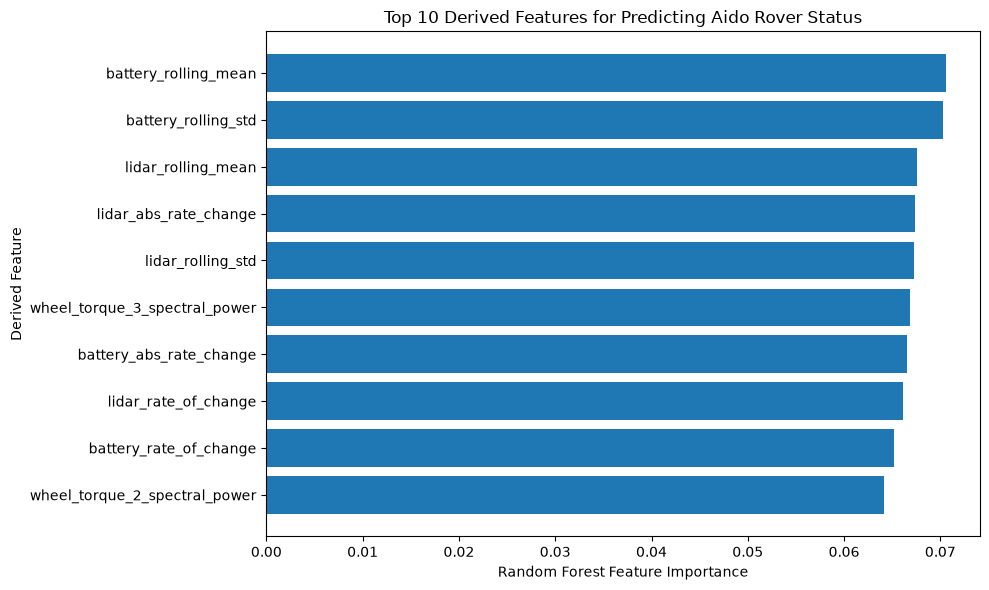

In [33]:
plt.figure(figsize=(10, 6))

plt.barh(
    rover_top10["feature"][::-1],
    rover_top10["importance"][::-1]
)

plt.title(
    "Top 10 Derived Features for Predicting Aido Rover Status"
)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Derived Feature")
plt.tight_layout()
plt.show()

**Finding:** Battery rolling mean was the highest-ranked derived feature
with a Random Forest importance of 0.0706, followed closely by battery rolling
standard deviation at 0.0703. However, the top feature importance scores were
very similar, ranging from approximately 0.064 to 0.071. This indicates that
Aido Rover status is not determined by one dominant measurement. Instead,
temporal averages, local variability, rates of change, and wheel-torque
frequency features contribute jointly to status prediction.

## Aido Rover Feature Importance Analysis

The two highest-ranked features were battery rolling mean and battery rolling
standard deviation. The rolling mean measures the local operating level of the
battery, while the rolling standard deviation measures short-term instability.

This parallels computer vision feature extraction. A rolling mean is similar
to a smoothing filter that summarizes nearby pixels, while rolling standard
deviation resembles a local texture descriptor that measures variation within
an image region.

LiDAR rolling mean, LiDAR rolling standard deviation, and LiDAR rate-of-change
features also appeared in the top ten. This suggests that both the local level
and rapid movement of LiDAR readings provide useful information about Rover
operating status.

Wheel-torque spectral-power features were also important. Spectral power
measures the strength of repeated fluctuations in the torque signal and can
represent vibration or recurring mechanical load patterns. This is similar to
frequency-domain features in computer vision, which identify repeated textures
and spatial patterns.

Because the top importance values are close together, the result suggests that
the model combines multiple complementary feature groups rather than relying
on a single sensor measurement.

# 3. Fari Interaction Feature Analysis

This section generates a synthetic Fari interaction dataset and applies a
Random Forest model to determine which session-level features are most
predictive of high-quality interactions.

In [34]:
fari_rows = 2000
rng = np.random.default_rng(RANDOM_SEED)

fari_df = pd.DataFrame({
    "response_length": rng.normal(
        loc=120,
        scale=35,
        size=fari_rows
    ).clip(20, 300),

    "sentiment_score": rng.uniform(
        -1,
        1,
        size=fari_rows
    ),

    "topic_coherence": rng.beta(
        5,
        2,
        size=fari_rows
    ),

    "latency_ms": rng.normal(
        loc=850,
        scale=250,
        size=fari_rows
    ).clip(100, 2500),

    "session_duration": rng.normal(
        loc=12,
        scale=4,
        size=fari_rows
    ).clip(1, 40)
})

quality_score = (
    1.8 * fari_df["topic_coherence"]
    + 0.7 * fari_df["sentiment_score"]
    - 0.0005 * fari_df["latency_ms"]
    + 0.015 * fari_df["response_length"]
    + 0.02 * fari_df["session_duration"]
    + rng.normal(0, 0.25, fari_rows)
)

quality_threshold = quality_score.median()

fari_df["quality_label"] = np.where(
    quality_score >= quality_threshold,
    "high",
    "low"
)

print("Fari dataset shape:", fari_df.shape)
print()
print(fari_df["quality_label"].value_counts())

fari_df.head()

Fari dataset shape: (2000, 6)

quality_label
low     1000
high    1000
Name: count, dtype: int64


,response_length,sentiment_score,topic_coherence,latency_ms,session_duration,quality_label
0,130.665098,-0.915308,0.726866,687.930656,12.597433,low
1,83.600556,-0.110124,0.766222,996.918884,11.617524,low
2,146.265792,0.093976,0.769563,645.935047,16.728961,high
3,152.919765,-0.706514,0.859027,983.367878,20.051916,high
4,51.713768,-0.327428,0.907225,953.460234,13.825801,low


In [35]:
fari_output_path = Path(
    "../data/synthetic_fari_sessions.csv"
)

fari_df.to_csv(
    fari_output_path,
    index=False
)

print("Fari dataset saved to:")
print(fari_output_path)

Fari dataset saved to:
../data/synthetic_fari_sessions.csv


In [36]:
fari_quality_table = pd.DataFrame({
    "data_type": fari_df.dtypes.astype(str),
    "missing_count": fari_df.isnull().sum(),
    "missing_percent": (
        fari_df.isnull().mean() * 100
    ).round(2),
    "unique_values": fari_df.nunique()
})

print("Duplicate rows:", fari_df.duplicated().sum())

fari_quality_table

Duplicate rows: 0


,data_type,missing_count,missing_percent,unique_values
response_length,float64,0,0.0,1994
sentiment_score,float64,0,0.0,2000
topic_coherence,float64,0,0.0,2000
latency_ms,float64,0,0.0,1997
session_duration,float64,0,0.0,1996
quality_label,str,0,0.0,2


### Fari Data Quality Finding

The synthetic Fari dataset contains 2,000 session records and six columns.
No missing values were introduced, and the high- and low-quality classes are
balanced. Numeric variables were constrained to realistic ranges before model
training.

In [37]:
fari_features = [
    "response_length",
    "sentiment_score",
    "topic_coherence",
    "latency_ms",
    "session_duration"
]

X_fari = fari_df[fari_features]
y_fari = fari_df["quality_label"]

print("X_fari shape:", X_fari.shape)
print("y_fari shape:", y_fari.shape)

X_fari shape: (2000, 5)
y_fari shape: (2000,)


In [38]:
X_fari_train, X_fari_test, y_fari_train, y_fari_test = train_test_split(
    X_fari,
    y_fari,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y_fari
)

print("Fari training rows:", len(X_fari_train))
print("Fari testing rows:", len(X_fari_test))

Fari training rows: 1400
Fari testing rows: 600


In [39]:
fari_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    class_weight="balanced",
    n_jobs=-1
)

fari_model.fit(
    X_fari_train,
    y_fari_train
)

print("Fari Random Forest training completed.")

Fari Random Forest training completed.


In [40]:
fari_predictions = fari_model.predict(
    X_fari_test
)

fari_accuracy = accuracy_score(
    y_fari_test,
    fari_predictions
)

print("Fari test accuracy:", round(fari_accuracy, 4))
print()
print("Fari Classification Report:")
print(
    classification_report(
        y_fari_test,
        fari_predictions,
        zero_division=0
    )
)

Fari test accuracy: 0.8783

Fari Classification Report:
              precision    recall  f1-score   support

        high       0.87      0.89      0.88       300
         low       0.89      0.87      0.88       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600



In [41]:
fari_importance = pd.DataFrame({
    "feature": fari_features,
    "importance": fari_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

fari_importance

,feature,importance
0,response_length,0.384714
1,sentiment_score,0.295451
2,topic_coherence,0.156744
3,latency_ms,0.096397
4,session_duration,0.066693


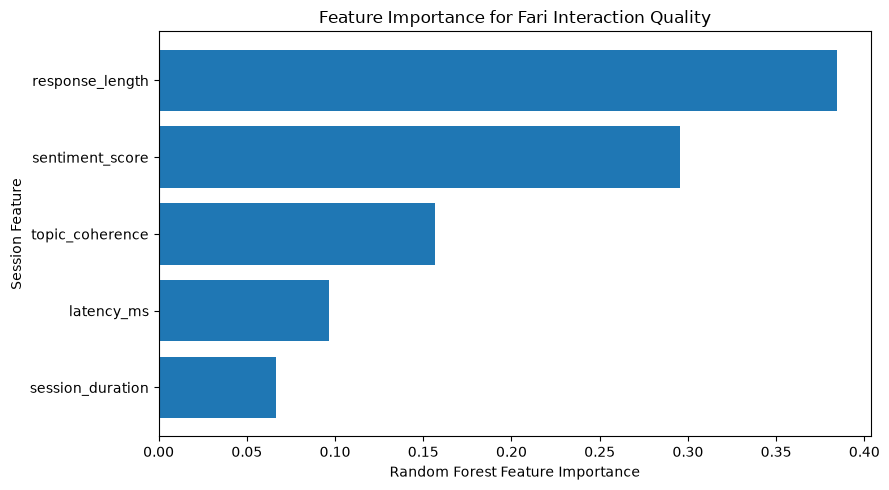

In [42]:
plt.figure(figsize=(9, 5))

plt.barh(
    fari_importance["feature"][::-1],
    fari_importance["importance"][::-1]
)

plt.title(
    "Feature Importance for Fari Interaction Quality"
)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Session Feature")
plt.tight_layout()
plt.show()

**Finding:** Response length was the strongest predictor of Fari interaction
quality, with a Random Forest importance of 0.3847. Sentiment score ranked
second with an importance of 0.2955, followed by topic coherence at 0.1567.
Together, response length and sentiment accounted for most of the model's
predictive importance. This suggests that both the amount of information in
a response and its emotional tone are central indicators of high-quality Fari
interactions.

## Fari Feature Importance Analysis

The strongest Fari predictor was response length. This suggests that very short
or insufficiently detailed responses may be associated with lower interaction
quality, while responses containing an appropriate amount of information are
more likely to support a high-quality session.

Sentiment score was the second most important feature. This indicates that the
emotional tone of the interaction provides a strong signal of session quality.
More positive sentiment is likely to be associated with more successful and
engaging interactions.

Topic coherence ranked third, showing that staying focused on the user's topic
also contributes meaningfully to quality. Latency and session duration were
less influential, although they still added useful predictive information.

The Random Forest achieved approximately 88% test accuracy, suggesting that
these five session-level features captured a substantial portion of the
synthetic interaction-quality pattern.

In [43]:
rover_summary = rover_importance.head(5).copy()
rover_summary["platform"] = "Aido Rover"

fari_summary = fari_importance.head(5).copy()
fari_summary["platform"] = "Fari"

comparison_table = pd.concat(
    [rover_summary, fari_summary],
    ignore_index=True
)

comparison_table[
    ["platform", "feature", "importance"]
]

,platform,feature,importance
0,Aido Rover,battery_rolling_mean,0.070588
1,Aido Rover,battery_rolling_std,0.070319
2,Aido Rover,lidar_rolling_mean,0.067617
3,Aido Rover,lidar_abs_rate_change,0.067353
4,Aido Rover,lidar_rolling_std,0.067307
5,Fari,response_length,0.384714
6,Fari,sentiment_score,0.295451
7,Fari,topic_coherence,0.156744
8,Fari,latency_ms,0.096397
9,Fari,session_duration,0.066693


# 4. Aido Rover and Fari Comparison

The Aido Rover and Fari models showed different feature-importance patterns.

For the Aido Rover, the most important feature was battery rolling mean with
an importance of 0.0706. However, the Rover top-ten importance values were
close together, ranging from approximately 0.064 to 0.071. This indicates that
Rover operating status depends on a combination of rolling statistics,
rate-of-change features, and wheel-torque frequency features rather than one
dominant predictor.

For Fari, response length was clearly the strongest feature with an importance
of 0.3847, followed by sentiment score at 0.2955. Unlike the Rover model, the
Fari model concentrated much more importance in its top two features.

This difference reflects the operational context of each platform. Rover health
is a multi-sensor physical condition that requires several complementary
signals. Fari interaction quality is more strongly associated with a small
number of conversational characteristics, especially response length and
sentiment.

In [44]:
output_dir = Path("../dashboard/data")
output_dir.mkdir(parents=True, exist_ok=True)

rover_importance.to_csv(
    output_dir / "rover_feature_importance.csv",
    index=False
)

fari_importance.to_csv(
    output_dir / "fari_feature_importance.csv",
    index=False
)

print("Feature importance files saved successfully.")
print(output_dir / "rover_feature_importance.csv")
print(output_dir / "fari_feature_importance.csv")

Feature importance files saved successfully.
../dashboard/data/rover_feature_importance.csv
../dashboard/data/fari_feature_importance.csv


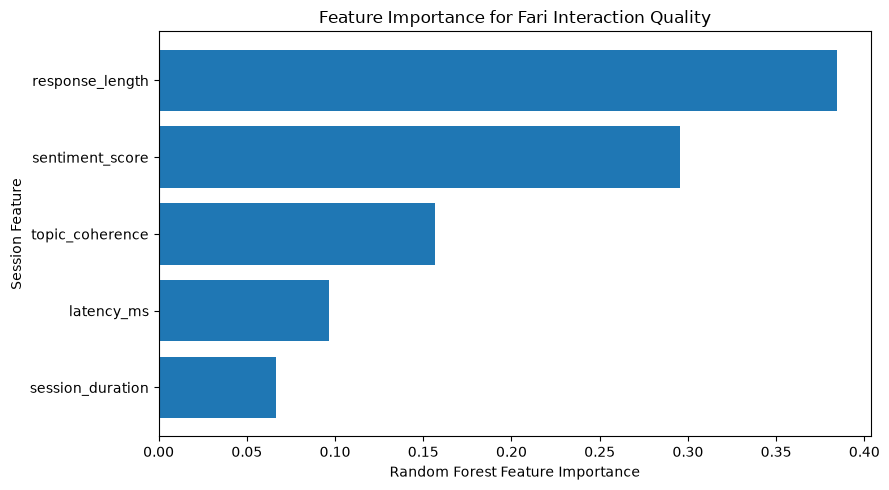

Chart saved to: ../dashboard/data/fari_feature_importance.png


In [45]:
fari_chart_path = output_dir / "fari_feature_importance.png"

plt.figure(figsize=(9, 5))

plt.barh(
    fari_importance["feature"][::-1],
    fari_importance["importance"][::-1]
)

plt.title("Feature Importance for Fari Interaction Quality")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Session Feature")
plt.tight_layout()

plt.savefig(
    fari_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", fari_chart_path)

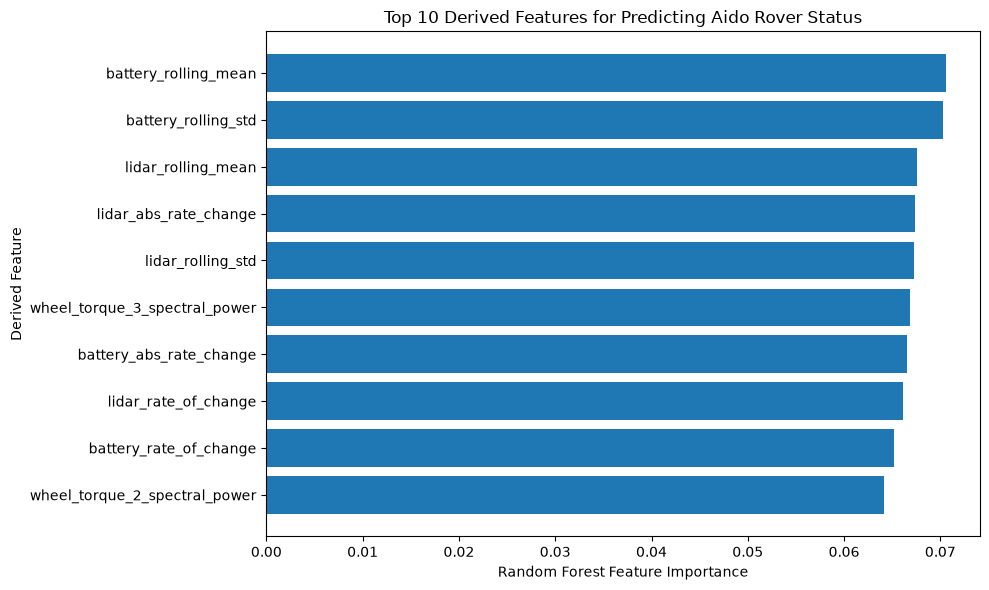

Chart saved to: ../dashboard/data/rover_feature_importance.png


In [46]:
rover_chart_path = output_dir / "rover_feature_importance.png"

plt.figure(figsize=(10, 6))

plt.barh(
    rover_top10["feature"][::-1],
    rover_top10["importance"][::-1]
)

plt.title("Top 10 Derived Features for Predicting Aido Rover Status")
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Derived Feature")
plt.tight_layout()

plt.savefig(
    rover_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", rover_chart_path)

# 5. Conclusion

This Week 5 analysis demonstrated that computer vision feature-extraction
concepts can be transferred to both robot sensor streams and interaction data.

For Aido Rover, rolling statistics, sensor rates of change, and frequency-domain
wheel-torque features jointly supported status prediction. No single Rover
feature dominated the model, which reflects the multi-sensor nature of physical
robot health.

For Fari, response length and sentiment score were the two strongest predictors
of interaction quality. The Fari model achieved approximately 88% test accuracy,
indicating that the five session-level features captured a meaningful synthetic
quality pattern.

The results provide pre-computed feature rankings that can later be integrated
into automated reports and the Week 7 dashboard.